# Customer Intelligence / Country Segmentation Notebook

## Unsupervised Learning on Country Data

### Goals
- Load and inspect the data
- Clean and preprocess features
- Apply scaling
- Find the best number of clusters with K-Means
- Try DBSCAN as a second clustering method
- Visualize clusters with PCA
- Create simple country-level insights


## 1) Install required libraries

## 2) Import libraries

In [1]:
import io
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

sns.set(style='whitegrid')
pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 100)

## 3) Load the dataset

Load `Country-data.csv` (place it in the same folder as this notebook).


In [2]:
df = pd.read_csv('Country-data.csv')
df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


## 4) Quick inspection

In [3]:
print('Shape:', df.shape)
display(df.head())
display(df.info())
display(df.describe(include='all').T)

Shape: (167, 10)


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB


None

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
country,167,167,Afghanistan,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
child_mort,167.0,NaN,NaN,NaN,38.27006,40.328931,2.6,8.25,19.3,62.1,208.0
exports,167.0,NaN,NaN,NaN,41.108976,27.41201,0.109,23.8,35.0,51.35,200.0
health,167.0,NaN,NaN,NaN,6.815689,2.746837,1.81,4.92,6.32,8.6,17.9
imports,167.0,NaN,NaN,NaN,46.890215,24.209589,0.0659,30.2,43.3,58.75,174.0
income,167.0,NaN,NaN,NaN,17144.688623,19278.067698,609.0,3355.0,9960.0,22800.0,125000.0
inflation,167.0,NaN,NaN,NaN,7.781832,10.570704,-4.21,1.81,5.39,10.75,104.0
life_expec,167.0,NaN,NaN,NaN,70.555689,8.893172,32.1,65.3,73.1,76.8,82.8
total_fer,167.0,NaN,NaN,NaN,2.947964,1.513848,1.15,1.795,2.41,3.88,7.49
gdpp,167.0,NaN,NaN,NaN,12964.155689,18328.704809,231.0,1330.0,4660.0,14050.0,105000.0


## 5) Expected columns

This dataset is commonly used for country clustering and usually contains:
- country
- child_mort
- exports
- health
- imports
- income
- inflation
- life_expec
- total_fer
- gdpp


In [4]:
print('Columns:', df.columns.tolist())

Columns: ['country', 'child_mort', 'exports', 'health', 'imports', 'income', 'inflation', 'life_expec', 'total_fer', 'gdpp']


## 6) Basic cleaning

Handle missing values, remove duplicates, and make sure numeric columns are clean.

In [5]:
df = df.copy()
df.columns = [c.strip().lower() for c in df.columns]
df = df.drop_duplicates()

for col in df.columns:
    if col != 'country':
        df[col] = pd.to_numeric(df[col], errors='coerce')

numeric_cols = [c for c in df.columns if c != 'country']
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

df.isna().sum()

country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64

## 7) Exploratory Data Analysis

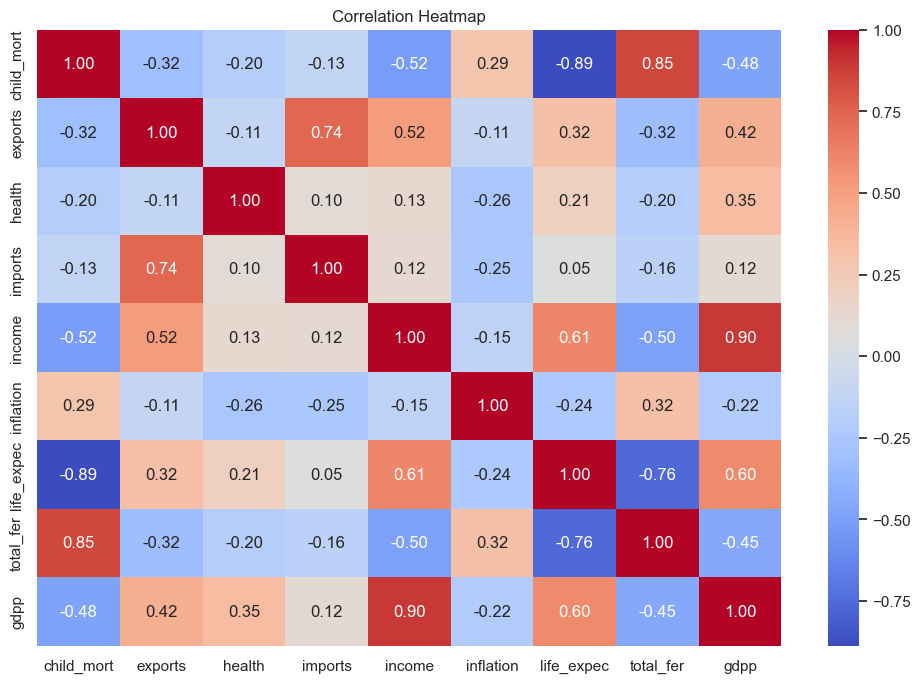

In [6]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.select_dtypes(include=np.number).corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

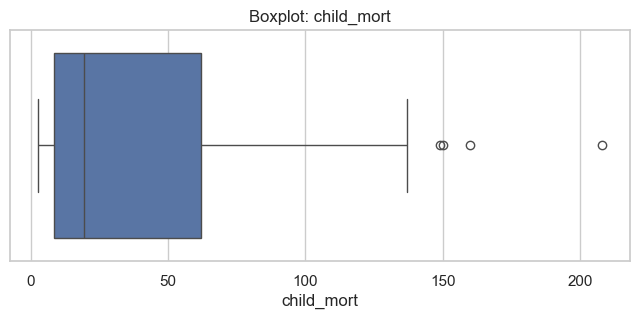

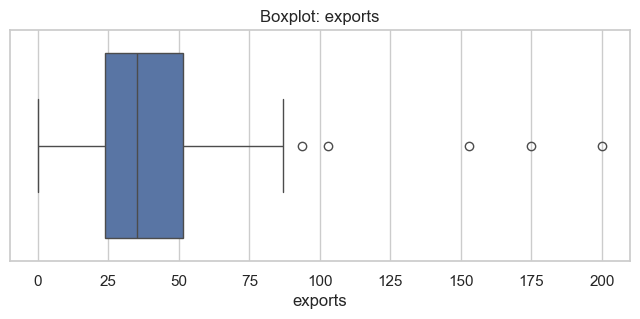

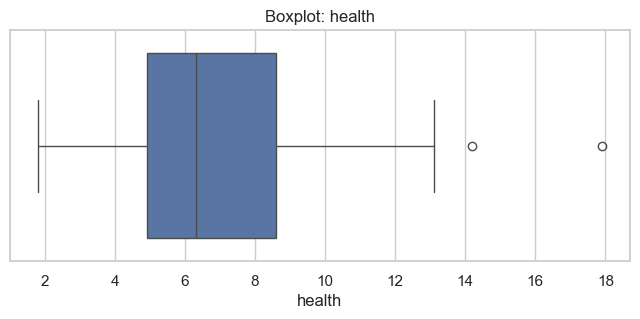

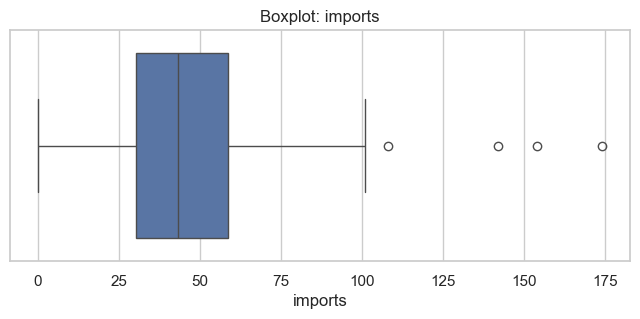

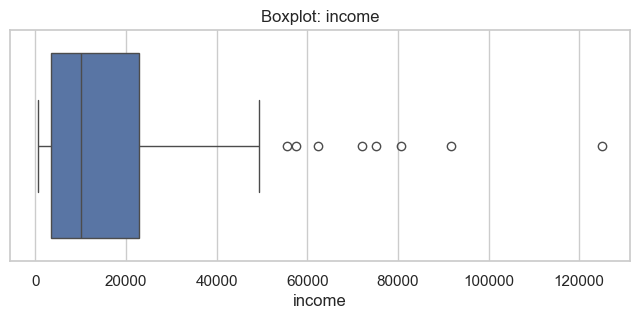

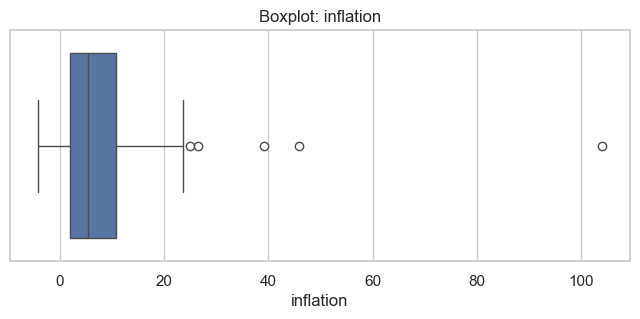

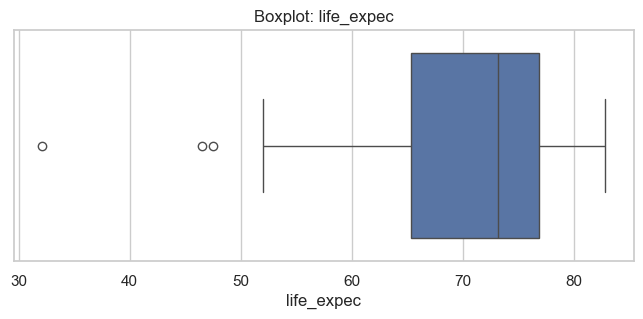

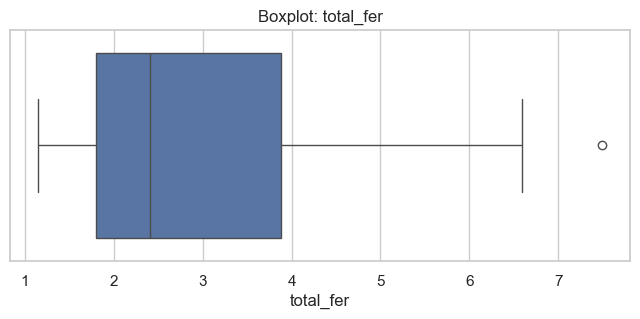

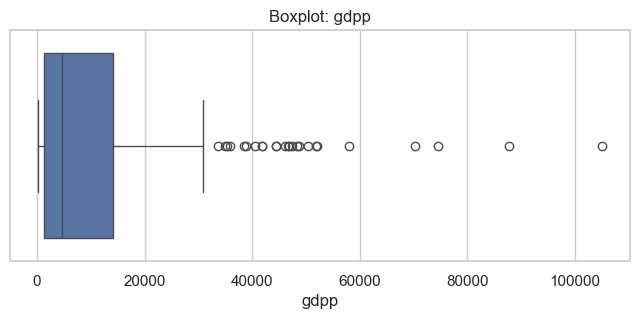

In [7]:
for col in numeric_cols:
    plt.figure(figsize=(8, 3))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot: {col}')
    plt.show()

## 8) Feature scaling

Clustering works better when features are on the same scale.

In [8]:
features = df.drop(columns=['country'], errors='ignore')
scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)
X_scaled.shape

(167, 9)

## 9) K-Means: Elbow method

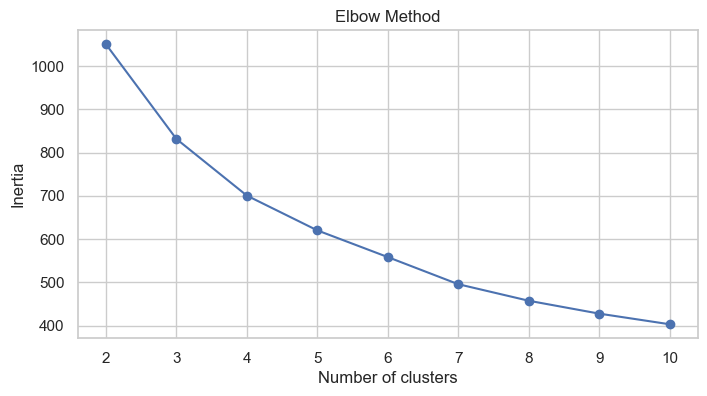

In [9]:
inertias = []
k_values = range(2, 11)

for k in k_values:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    model.fit(X_scaled)
    inertias.append(model.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(list(k_values), inertias, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.show()

## 10) Train K-Means

In [10]:
sil_scores = []
for k in k_values:
    m = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = m.fit_predict(X_scaled)
    sil_scores.append(silhouette_score(X_scaled, labels))

for k, s in zip(k_values, sil_scores):
    print(f'k={k}: silhouette={s:.4f}')

best_k = 3
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
df['kmeans_cluster'] = kmeans.fit_predict(X_scaled)

print('\nSilhouette Score (k=3):', silhouette_score(X_scaled, df['kmeans_cluster']))
df[['country', 'kmeans_cluster']].head() if 'country' in df.columns else df[['kmeans_cluster']].head()

k=2: silhouette=0.2874
k=3: silhouette=0.2833
k=4: silhouette=0.2960
k=5: silhouette=0.2993
k=6: silhouette=0.2287
k=7: silhouette=0.2477
k=8: silhouette=0.2388
k=9: silhouette=0.2073
k=10: silhouette=0.2022

Silhouette Score (k=3): 0.28329575683463126


,country,kmeans_cluster
0,Afghanistan,1
1,Albania,2
2,Algeria,2
3,Angola,1
4,Antigua and Barbuda,2


## 11) Try DBSCAN

In [11]:
dbscan = DBSCAN(eps=1.5, min_samples=5)
df['dbscan_cluster'] = dbscan.fit_predict(X_scaled)

print(df['dbscan_cluster'].value_counts().sort_index())

n_noise = (df['dbscan_cluster'] == -1).sum()
n_clusters_dbscan = len(set(df['dbscan_cluster'])) - (1 if -1 in df['dbscan_cluster'].values else 0)
print(f'\nDBSCAN found {n_clusters_dbscan} cluster(s) and {n_noise} noise points.')
print('DBSCAN performs poorly here because country-level features form a continuum')
print('rather than well-separated, similar-density blobs -- K-Means is the better fit for this data.')

dbscan_cluster
-1     30
 0    137
Name: count, dtype: int64

DBSCAN found 1 cluster(s) and 30 noise points.
DBSCAN performs poorly here because country-level features form a continuum
rather than well-separated, similar-density blobs -- K-Means is the better fit for this data.


## 12) PCA visualization

Explained variance ratio: [0.4595174  0.17181626]
Total variance captured by 2 components: 63.1%


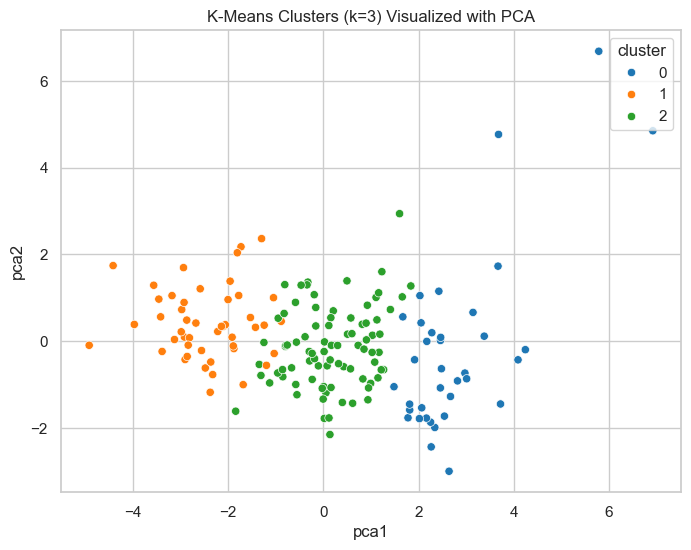

In [12]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print('Explained variance ratio:', pca.explained_variance_ratio_)
print(f'Total variance captured by 2 components: {sum(pca.explained_variance_ratio_)*100:.1f}%')

viz = pd.DataFrame({
    'pca1': X_pca[:, 0],
    'pca2': X_pca[:, 1],
    'cluster': df['kmeans_cluster']
})

plt.figure(figsize=(8, 6))
sns.scatterplot(data=viz, x='pca1', y='pca2', hue='cluster', palette='tab10')
plt.title('K-Means Clusters (k=3) Visualized with PCA')
plt.show()

## 13) Cluster profiling

In [13]:
profile = df.groupby('kmeans_cluster')[numeric_cols].mean().round(2)
profile

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
kmeans_cluster,,,,,,,,,
0,5.00,58.74,8.81,51.49,45672.22,2.67,80.13,1.75,42494.44
1,92.96,29.15,6.39,42.32,3942.40,12.02,59.19,5.01,1922.38
2,21.93,40.24,6.20,47.47,12305.60,7.60,72.81,2.31,6486.45


In [14]:
print('Cluster sizes:')
print(df['kmeans_cluster'].value_counts().sort_index())

cluster_labels = {
    0: 'Developed',
    1: 'Underdeveloped / Needs Aid',
    2: 'Developing / Middle-income'
}

for c in sorted(df['kmeans_cluster'].unique()):
    countries = df[df['kmeans_cluster'] == c]['country'].tolist()
    print(f"\nCluster {c} - {cluster_labels.get(c, '')} ({len(countries)} countries):")
    print(countries)

Cluster sizes:
kmeans_cluster
0    36
1    47
2    84
Name: count, dtype: int64

Cluster 0 - Developed (36 countries):
['Australia', 'Austria', 'Bahrain', 'Belgium', 'Brunei', 'Canada', 'Cyprus', 'Czech Republic', 'Denmark', 'Finland', 'France', 'Germany', 'Greece', 'Iceland', 'Ireland', 'Israel', 'Italy', 'Japan', 'Kuwait', 'Luxembourg', 'Malta', 'Netherlands', 'New Zealand', 'Norway', 'Portugal', 'Qatar', 'Singapore', 'Slovak Republic', 'Slovenia', 'South Korea', 'Spain', 'Sweden', 'Switzerland', 'United Arab Emirates', 'United Kingdom', 'United States']

Cluster 1 - Underdeveloped / Needs Aid (47 countries):
['Afghanistan', 'Angola', 'Benin', 'Botswana', 'Burkina Faso', 'Burundi', 'Cameroon', 'Central African Republic', 'Chad', 'Comoros', 'Congo, Dem. Rep.', 'Congo, Rep.', "Cote d'Ivoire", 'Equatorial Guinea', 'Eritrea', 'Gabon', 'Gambia', 'Ghana', 'Guinea', 'Guinea-Bissau', 'Haiti', 'Iraq', 'Kenya', 'Kiribati', 'Lao', 'Lesotho', 'Liberia', 'Madagascar', 'Malawi', 'Mali', 'Mauritani

## 14) Final insights

**Cluster profile summary (k=3, KMeans, silhouette ≈ 0.283):**

| Cluster | Size | child_mort | income | gdpp | life_expec | Label |
|---|---|---|---|---|---|---|
| 0 | 36 | 5.0 | $45,672 | $42,494 | 80.1 | Developed |
| 1 | 47 | 93.0 | $3,942 | $1,922 | 59.2 | Underdeveloped / needs aid |
| 2 | 84 | 21.9 | $12,306 | $6,486 | 72.8 | Developing / middle-income |

**Observations:**

1. **High child mortality:** Cluster 1 has by far the highest average child mortality (~93 deaths per 1,000 live births vs. ~5 in Cluster 0), driven mostly by Sub-Saharan African nations (Chad, Central African Republic, Nigeria, Mali, etc.) plus Afghanistan, Haiti, and Yemen.

2. **High income and gdpp:** Cluster 0 (36 countries — the US, UK, Germany, Japan, the Nordics, and Gulf states) dominates on both income (~$45.7K) and gdpp (~$42.5K), roughly 20× higher than Cluster 1.

3. **Most underdeveloped:** Cluster 1 again — it combines the lowest income and gdpp with the lowest life expectancy (~59 years) and highest fertility rate (~5 children per woman), a classic signature of lower development stage.

4. **Countries to prioritize for aid:** All 47 countries in Cluster 1 are reasonable aid-priority candidates, with Afghanistan, Nigeria, Chad, Central African Republic, and Yemen standing out as extreme cases (very high child mortality combined with very low income).

5. **DBSCAN vs. K-Means:** DBSCAN collapsed almost the entire dataset into a single cluster plus 30 noise points, because the features form a continuum rather than density-separated groups. This makes K-Means (which partitions by distance rather than density) the more useful method for this particular dataset.
